# 2. Spatial methods and challenges

From expression alone to **spatial** structure. Because the data is points in a plane,
a **graph** of neighbouring cells is the natural representation, and most spatial methods
are built on it. We look at the neighbourhood graph, neighbourhood enrichment, spatial
domains, a brief cell-cell communication analysis, and the open challenges.

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np, pandas as pd
import scanpy as sc, squidpy as sq
import matplotlib.pyplot as plt
import topo_utils as tu
sc.settings.verbosity = 1

/opt/conda/envs/env-st-topo/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/opt/conda/envs/env-st-topo/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
sub = sc.read_h5ad(tu.results_dir() / 'section.h5ad')
print('section:', sub.shape)

section: (220825, 480)


## The spatial neighbourhood graph

Connect each cell to its spatial neighbours (Delaunay triangulation, k-nearest, or a
radius). This graph comes from the coordinates and is the substrate for
spatial statistics and for graph neural networks.

In [3]:
sq.gr.spatial_neighbors(sub, coord_type='generic', delaunay=True)
A = sub.obsp['spatial_connectivities']
print('nodes:', sub.n_obs, '| edges:', int(A.nnz/2), '| mean degree:', round(A.nnz/sub.n_obs, 1))

INFO     Creating graph using `None` transform and `1` libraries.                                                  


/tmp/ipykernel_1683376/2919003307.py:1: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(sub, coord_type='generic', delaunay=True)


nodes: 220825 | edges: 662438 | mean degree: 6.0


## Neighbourhood enrichment

A permutation test: which cell types sit next to each other more (or less) than chance?
This is a first, interpretable read on tissue organisation.

  0%|          | 0/1000 [00:00<?, ?/s]

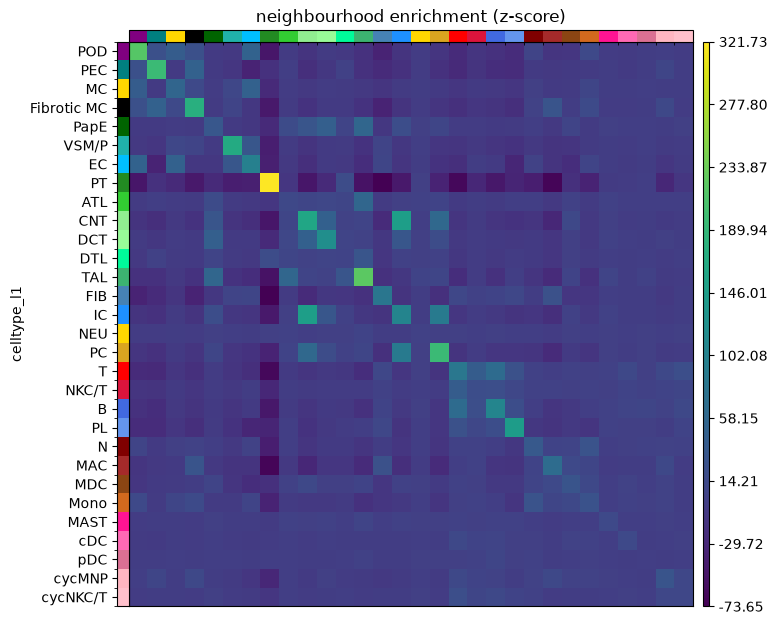

In [4]:
sq.gr.nhood_enrichment(sub, cluster_key='celltype_l1', seed=0)
sq.pl.nhood_enrichment(sub, cluster_key='celltype_l1', figsize=(6,6), title='neighbourhood enrichment (z-score)')

## Spatial domains and niches

**Domains** are coherent tissue regions; **niches** are recurring multi-cell
neighbourhoods. The method landscape is large and mostly graph-based, we mention it
rather than run it all:

- **SpaGCN** (graph convolution + histology), **STAGATE** (graph-attention autoencoder),
  **BANKSY** (augment each cell with neighbourhood summaries, then cluster),
  **CellCharter / nichePCA** (cluster neighbourhood-aware embeddings).

This object already has **nichePCA** domains, so we simply visualise and interpret them.

/opt/conda/envs/env-st-topo/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


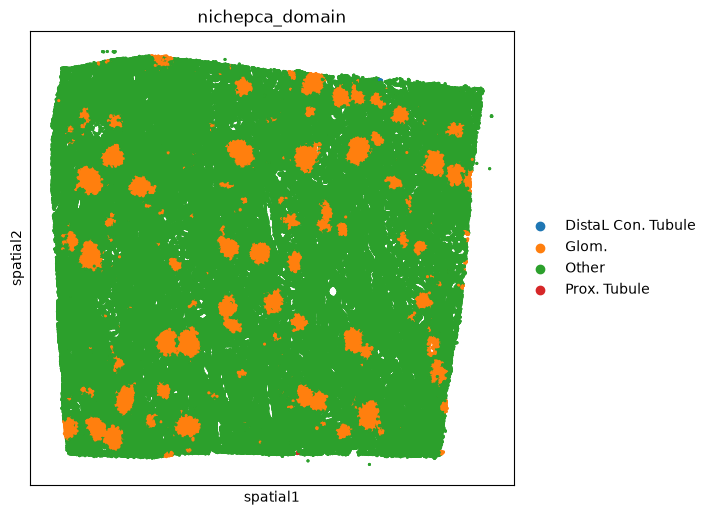

In [5]:
dom = 'nichepca_domain'
sq.pl.spatial_scatter(sub, color=dom, shape=None, size=6, figsize=(7,7))

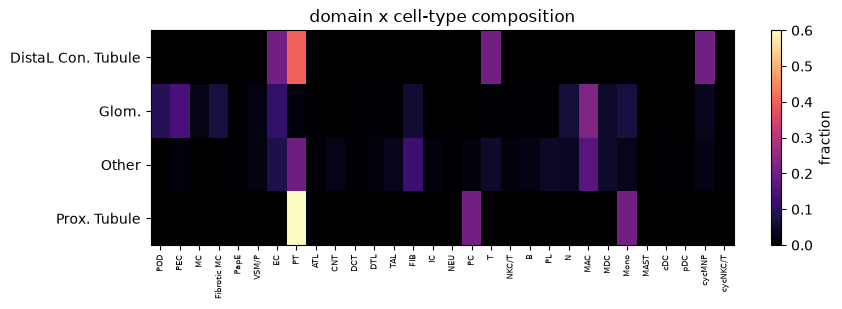

In [6]:
# domain x cell-type composition
comp = pd.crosstab(sub.obs[dom], sub.obs['celltype_l1'], normalize='index')
fig, axh = plt.subplots(figsize=(9,3.2)); im = axh.imshow(comp.values, aspect='auto', cmap='magma')
axh.set_yticks(range(len(comp))); axh.set_yticklabels(comp.index)
axh.set_xticks(range(comp.shape[1])); axh.set_xticklabels(comp.columns, rotation=90, fontsize=6)
axh.set_title('domain x cell-type composition'); fig.colorbar(im, label='fraction'); plt.tight_layout(); plt.show()

## Cell-cell communication

A standard question: do neighbouring cell types express matching **ligand-receptor (LR)**
pairs? Tools: CellPhoneDB, CellChat, LIANA, and spatial-aware `squidpy.gr.ligrec`. We run
a small permutation test on a few cell types using the LR table in `data/`.

54 LR pairs are in the 480-gene panel


/opt/conda/envs/env-st-topo/lib/python3.11/site-packages/squidpy/gr/_ligrec.py:399: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["clusters"] = data["clusters"].cat.remove_unused_categories()
/opt/conda/envs/env-st-topo/lib/python3.11/site-packages/squidpy/gr/_ligrec.py:408: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["clusters"] = cat.rename_categories(cluster_mapper)


  0%|          | 0/100 [00:00<?, ?permutation/s]

/opt/conda/envs/env-st-topo/lib/python3.11/site-packages/squidpy/pl/_ligrec.py:248: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
  if cluster_key not in adata.uns_keys():


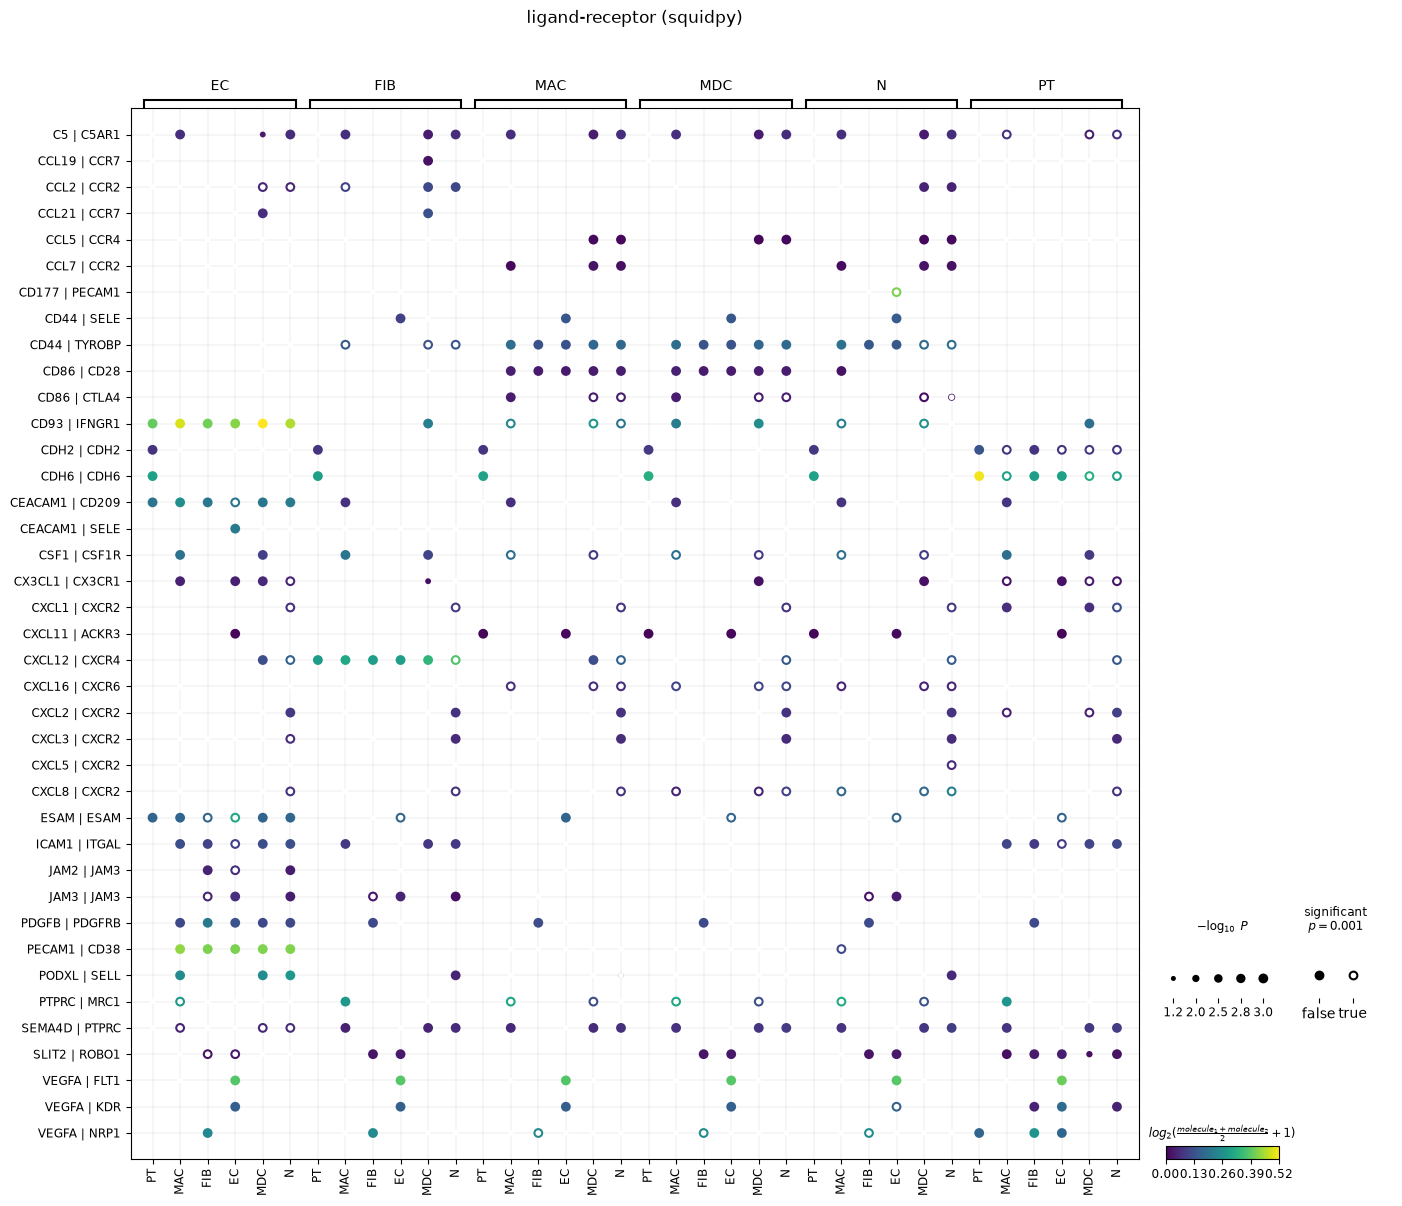

In [7]:
lr = tu.load_lr_pairs()
lr = lr[lr['source'].isin(sub.var_names) & lr['target'].isin(sub.var_names)]
print(f'{len(lr)} LR pairs are in the {sub.n_vars}-gene panel')
groups = list(sub.obs['celltype_l1'].value_counts().index[:6])
sq.gr.ligrec(sub, cluster_key='celltype_l1', interactions=lr[['source','target']],
             use_raw=False, n_perms=100, seed=0, clusters=groups)
sq.pl.ligrec(sub, cluster_key='celltype_l1', source_groups=groups, target_groups=groups,
             pvalue_threshold=0.05, remove_empty_interactions=True, title='ligand-receptor (squidpy)')

## Challenges

- **Segmentation.** Cell boundaries are estimated; mis-assigned transcripts corrupt
  expression, co-expression, and any communication score.
- **Sparsity and noise.** Few counts per cell; a targeted panel misses most genes.
- **Scale.** Millions of cells per slide, methods must be graph-sparse and batched.
- **Batch / patient effects** across samples and conditions.
- **Beyond pairwise.** Graphs and LR edges capture pairwise relations; **relay** signalling
  and multi-cell niches are higher-order, taken up in the topological / CellNEST part.

In [8]:
# fraction of zero entries in the cell x gene matrix
import scipy.sparse as sp
X = sub.layers['counts']; nnz = X.nnz if sp.issparse(X) else int((X!=0).sum())
print(f'zero fraction: {1 - nnz/(sub.n_obs*sub.n_vars):.1%}  ({sub.n_vars}-gene panel)')
print('median transcripts/cell:', int(np.median(sub.obs['n_transcripts'])) if 'n_transcripts' in sub.obs else 'n/a')

zero fraction: 94.1%  (480-gene panel)
median transcripts/cell: 60


### Recap

Coordinates gave us a graph; the graph gave us neighbourhood enrichment, domains, and
communication. The recurring limitation is that these are pairwise; relay signalling and
multi-cell niches are higher-order, taken up in the topological / CellNEST part.